# Portfolio Sophistication Report Demo

This notebook codifies the chart from the *Mas sofisticacion = mejor portfolio?* discussion: compare simple and sophisticated portfolio construction objectives side by side, then inspect whether extra complexity actually improves the portfolio.

The demo uses the same defensive stock universe used elsewhere in RiskOptima documentation. Returns are synthetic and seeded so the notebook runs without a market-data or article dependency.

In [1]:
from riskoptima import RiskOptima
print(RiskOptima.VERSION)

2.5.2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from riskoptima.reporting import (
    available_sophistication_methods,
    build_portfolio_sophistication_report,
    plot_portfolio_sophistication_report,
)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Define the existing RiskOptima portfolio universe

This is the same defensive/dividend-oriented stock universe shown in the main README and portfolio optimization notebook. We keep the labels and starting weights visible because they make the comparison easier to explain in interviews.

In [4]:
asset_data = [
    {"Asset": "MO", "Weight": 0.04, "Label": "Altria Group Inc.", "MarketCap": 110.0e9},
    {"Asset": "NWN", "Weight": 0.14, "Label": "Northwest Natural Gas", "MarketCap": 1.8e9},
    {"Asset": "BKH", "Weight": 0.01, "Label": "Black Hills Corp.", "MarketCap": 4.5e9},
    {"Asset": "ED", "Weight": 0.01, "Label": "Con Edison", "MarketCap": 30.0e9},
    {"Asset": "PEP", "Weight": 0.09, "Label": "PepsiCo Inc.", "MarketCap": 255.0e9},
    {"Asset": "NFG", "Weight": 0.16, "Label": "National Fuel Gas", "MarketCap": 5.6e9},
    {"Asset": "KO", "Weight": 0.06, "Label": "Coca-Cola Company", "MarketCap": 275.0e9},
    {"Asset": "FRT", "Weight": 0.28, "Label": "Federal Realty Inv. Trust", "MarketCap": 9.8e9},
    {"Asset": "GPC", "Weight": 0.16, "Label": "Genuine Parts Co.", "MarketCap": 25.3e9},
    {"Asset": "MSEX", "Weight": 0.05, "Label": "Middlesex Water Co.", "MarketCap": 2.4e9},
]
portfolio = pd.DataFrame(asset_data).set_index("Asset")
portfolio

,Weight,Label,MarketCap
Asset,,,
MO,0.04,Altria Group Inc.,1.100000e+11
NWN,0.14,Northwest Natural Gas,1.800000e+09
BKH,0.01,Black Hills Corp.,4.500000e+09
ED,0.01,Con Edison,3.000000e+10
PEP,0.09,PepsiCo Inc.,2.550000e+11
NFG,0.16,National Fuel Gas,5.600000e+09
KO,0.06,Coca-Cola Company,2.750000e+11
FRT,0.28,Federal Realty Inv. Trust,9.800000e+09
GPC,0.16,Genuine Parts Co.,2.530000e+10


## 2. Generate reproducible asset returns

The article question is about portfolio construction, not data downloading. We therefore create a realistic defensive-equity return panel with a shared market factor, sector-style factors, and asset-specific noise. This keeps the notebook deterministic and makes it safe for CI or offline execution.

In [6]:
rng = np.random.default_rng(42)
dates = pd.bdate_range("2014-04-08", "2024-06-28")
n_assets = len(portfolio)

market = rng.normal(0.00028, 0.0085, size=(len(dates), 1))
defensive = rng.normal(0.00008, 0.0040, size=(len(dates), 1))
real_assets = rng.normal(0.00005, 0.0060, size=(len(dates), 1))
idiosyncratic = rng.normal(0.0, 0.0065, size=(len(dates), n_assets))

betas = np.array([0.75, 0.55, 0.65, 0.50, 0.70, 0.80, 0.62, 1.00, 0.82, 0.45])
defensive_loadings = np.array([0.30, 0.75, 0.65, 0.80, 0.50, 0.45, 0.55, 0.15, 0.35, 0.70])
real_asset_loadings = np.array([0.10, 0.25, 0.20, 0.20, 0.05, 0.35, 0.05, 0.75, 0.10, 0.15])
drifts = np.array([0.00018, 0.00012, 0.00013, 0.00011, 0.00020, 0.00016, 0.00018, 0.00014, 0.00017, 0.00010])

returns = pd.DataFrame(
    market @ betas.reshape(1, -1)
    + defensive @ defensive_loadings.reshape(1, -1)
    + real_assets @ real_asset_loadings.reshape(1, -1)
    + idiosyncratic
    + drifts,
    index=dates,
    columns=portfolio.index,
)
returns.head()

Asset,MO,NWN,BKH,ED,PEP,NFG,KO,FRT,GPC,MSEX
2014-04-08,-0.003397,-0.000935,-0.010224,0.002530,-0.009993,0.002955,-0.007314,-0.001439,0.009333,0.003724
2014-04-09,0.002767,0.009393,-0.007241,0.009216,-0.013554,0.001835,-0.006428,-0.008911,-0.001176,0.005407
2014-04-10,0.012988,0.009841,0.009337,0.011759,0.009807,0.012039,0.008897,0.014034,-0.002790,0.006497
2014-04-11,-0.003017,0.005450,0.015276,-0.000006,0.005993,0.011336,-0.009045,0.005694,0.008828,-0.016063
2014-04-14,-0.017713,0.000018,-0.002479,-0.003837,-0.004429,-0.010303,-0.005168,-0.017329,-0.011661,-0.009816


## 3. Review the available construction methods

The method names match the chart: `MV`, `CVaR`, `EVaR`, `RLVaR`, `WR`, `CDaR`, `EDaR`, `RLDaR`, `MDD`, and `1N`. Some labels are implemented as transparent proxies so users can run the comparison without adding a specialised external optimiser dependency.

In [8]:
available_sophistication_methods()

,method,description
0,MV,minimum variance portfolio
1,CVaR,historical expected shortfall proxy
2,EVaR,entropic value-at-risk proxy
3,RLVaR,robust tail loss proxy
4,WR,return-to-risk weighted portfolio
5,CDaR,conditional drawdown-at-risk proxy
6,EDaR,entropic drawdown-at-risk proxy
7,RLDaR,robust large drawdown proxy
8,MDD,minimum maximum drawdown proxy
9,1N,equal-weight portfolio


## 4. Build the report

The report returns a standard RiskOptima `RiskReport`. The key outputs are `weights`, `returns`, `wealth`, and `performance_table`, which can feed a notebook, dashboard, or exported image.

In [15]:
report = build_portfolio_sophistication_report(
    returns,
    methods=("MV", "CVaR", "EVaR", "RLVaR", "WR", "CDaR", "EDaR", "RLDaR", "MDD", "1N"),
    confidence=0.95,
    initial_value=100.0,
)

report.metrics["weights"].round(4)

,MV,CVaR,EVaR,RLVaR,WR,CDaR,EDaR,RLDaR,MDD,1N
Asset,,,,,,,,,,
MO,0.1001,0.1106,0.0900,0.1091,0.1000,0.1,0.0527,0.3528,0.3528,0.1
NWN,0.1553,0.1554,0.1311,0.1553,0.0000,0.1,0.1661,0.0000,0.0000,0.1
BKH,0.0454,0.0956,0.0758,0.0937,0.1085,0.1,0.0000,0.0000,0.0000,0.1
ED,0.1890,0.1695,0.1701,0.1692,0.0000,0.1,0.0000,0.0000,0.0000,0.1
PEP,0.0816,0.0009,0.0701,0.0020,0.0000,0.1,0.0000,0.0000,0.0000,0.1
NFG,0.0000,0.0000,0.0000,0.0000,0.0000,0.1,0.2097,0.0436,0.0436,0.1
KO,0.1486,0.1732,0.2045,0.1749,0.7915,0.1,0.0000,0.3081,0.3082,0.1
FRT,0.0000,0.0000,0.0000,0.0000,0.0000,0.1,0.2366,0.0000,0.0000,0.1
GPC,0.0017,0.0000,0.0000,0.0004,0.0000,0.1,0.1867,0.0000,0.0000,0.1


## 5. Plot the article-style comparison chart

The top panel compares cumulative wealth. The lower panel is intentionally table-first: it lets a reviewer check whether higher complexity improved the risk-adjusted profile or merely overfit a specific objective.

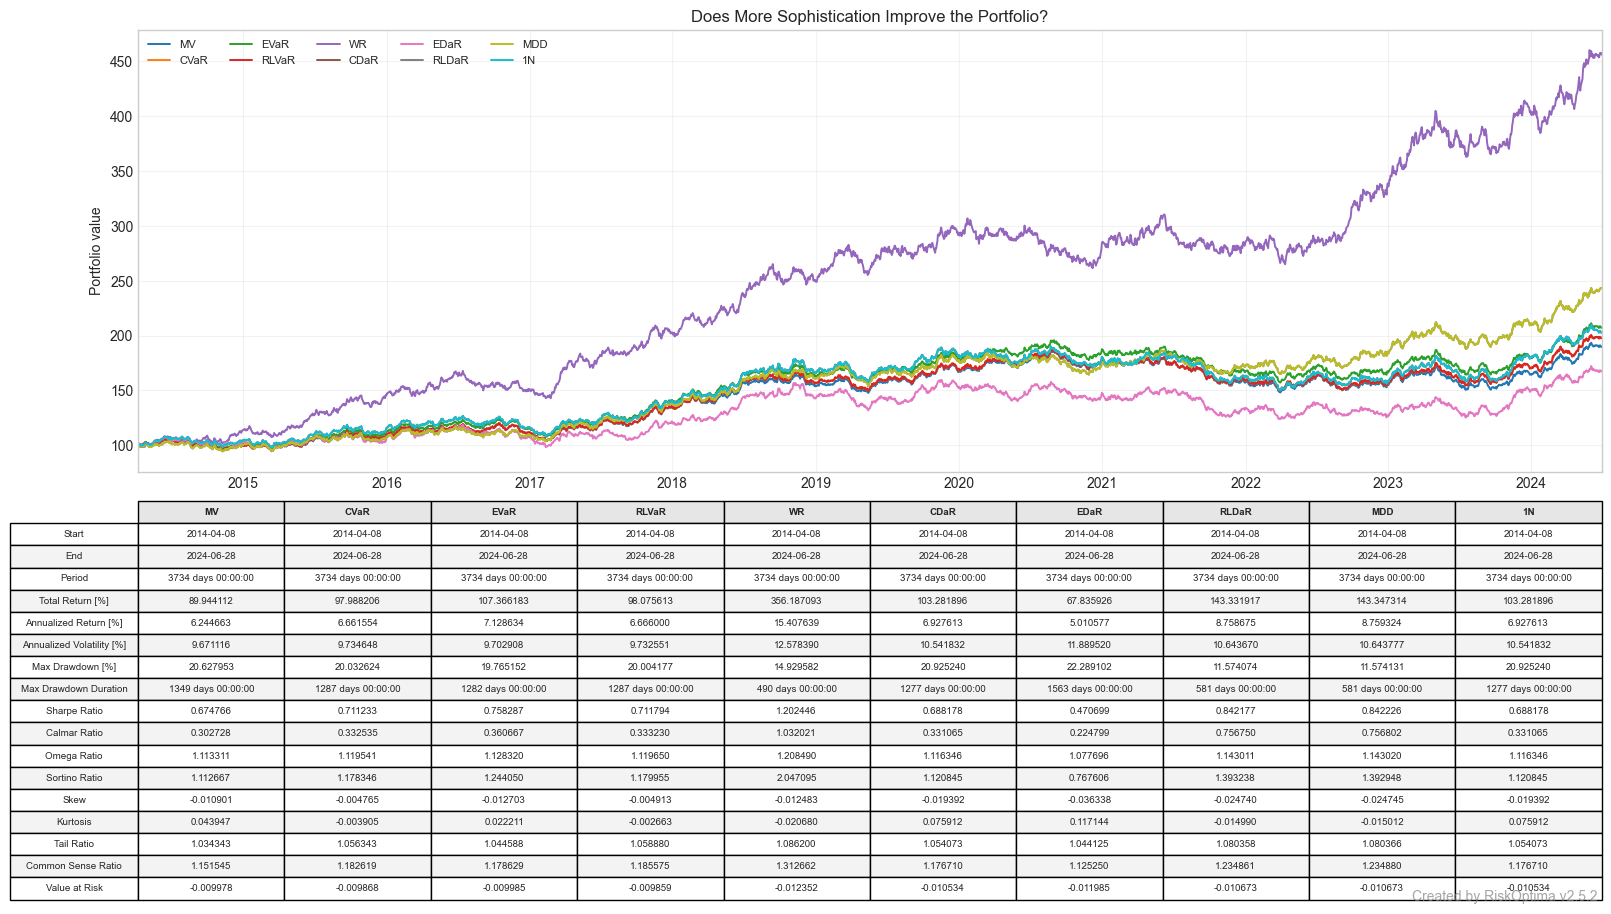

In [17]:
fig = plot_portfolio_sophistication_report(
    report,
    title="Does More Sophistication Improve the Portfolio?",
    figsize=(16, 9),
    table_fontsize=7,
)
plt.show()

## 6. Inspect the performance table directly

For automated workflows, use the raw table rather than parsing the plotted image. Values are already aligned by construction method.

In [19]:
report.metrics["performance_table"].round(4)

,MV,CVaR,EVaR,RLVaR,WR,CDaR,EDaR,RLDaR,MDD,1N
Start,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00,2014-04-08 00:00:00
End,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00
Period,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00,3734 days 00:00:00
Total Return [%],89.944112,97.988206,107.366183,98.075613,356.187093,103.281896,67.835926,143.331917,143.347314,103.281896
Annualized Return [%],6.244663,6.661554,7.128634,6.666,15.407639,6.927613,5.010577,8.758675,8.759324,6.927613
Annualized Volatility [%],9.671116,9.734648,9.702908,9.732551,12.57839,10.541832,11.88952,10.64367,10.643777,10.541832
Max Drawdown [%],20.627953,20.032624,19.765152,20.004177,14.929582,20.92524,22.289102,11.574074,11.574131,20.92524
Max Drawdown Duration,1349 days 00:00:00,1287 days 00:00:00,1282 days 00:00:00,1287 days 00:00:00,490 days 00:00:00,1277 days 00:00:00,1563 days 00:00:00,581 days 00:00:00,581 days 00:00:00,1277 days 00:00:00
Sharpe Ratio,0.674766,0.711233,0.758287,0.711794,1.202446,0.688178,0.470699,0.842177,0.842226,0.688178
Calmar Ratio,0.302728,0.332535,0.360667,0.33323,1.032021,0.331065,0.224799,0.75675,0.756802,0.331065


## 7. Practical interpretation

The useful interview point is not that the most complex label always wins. A solid quant workflow compares a simple benchmark (`1N`), a classic optimiser (`MV`), tail-risk objectives (`CVaR`, `EVaR`, `RLVaR`), and drawdown objectives (`CDaR`, `EDaR`, `RLDaR`, `MDD`) under the same data and metrics. That makes the sophistication trade-off explicit.